# Desarrollo de ejemplo 1
Aproximar la funcion 
$
    \phi(x) = \frac{1}{1+25x^{2}}
$
Por medio de polinomio de legendre de python con integración numerica. No vamos a explicar aun integracion numerica solo la vamos a usar para mejorar el recurso computacional


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import Legendre, leggauss

[]

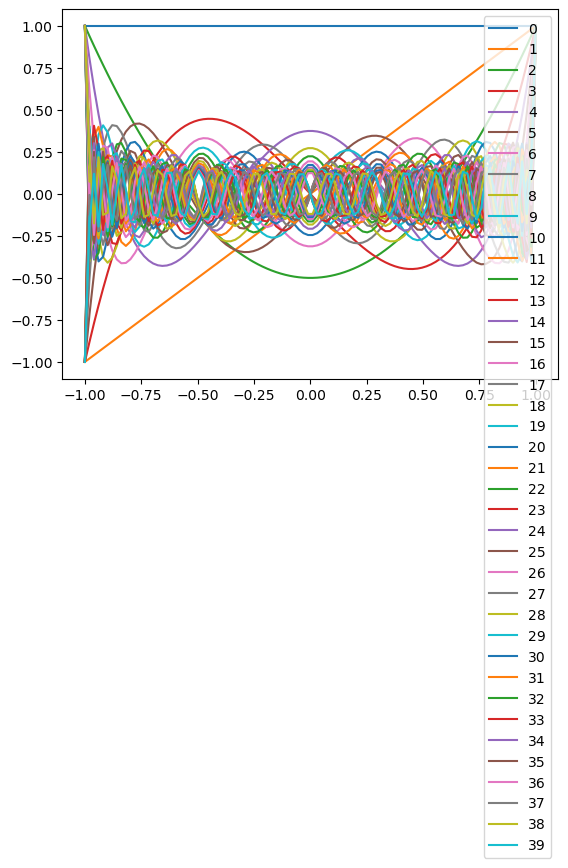

In [13]:
#Definir una familia de funciones
plt.figure()
x = np.linspace(-1, 1, 1000)
for order in range(40):
   # Attempt to generate legendre polynomials with numpy
   x, y = np.polynomial.legendre.Legendre.basis(order, [-1, 1]).linspace(100)
   plt.plot(x, y, label=order)

plt.legend()
plt.plot()    

Matriz K (primeros 6x6):
 [[ 2.          0.          0.         -0.          0.         -0.        ]
 [ 0.          0.66666667  0.          0.         -0.          0.        ]
 [ 0.          0.          0.4        -0.          0.          0.        ]
 [-0.          0.         -0.          0.28571429 -0.          0.        ]
 [ 0.         -0.          0.         -0.          0.22222222  0.        ]
 [-0.          0.          0.          0.          0.          0.18181818]]

Vector F:
 [ 0.54936031  0.         -0.18764177 -0.          0.09492635 -0.
 -0.05324663 -0.          0.031339   -0.         -0.01896606  0.
  0.0116887   0.         -0.00729653  0.          0.00459827  0.
 -0.00291917 -0.        ]

Coeficientes a:
 [ 0.27468015  0.         -0.46910443 -0.          0.42716857  0.
 -0.34610313 -0.          0.26638149 -0.         -0.19914365  0.
  0.14610872  0.         -0.10579963  0.          0.07587149  0.
 -0.05400468 -0.        ]


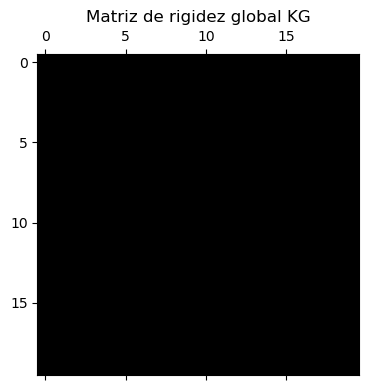

<Figure size 500x400 with 0 Axes>

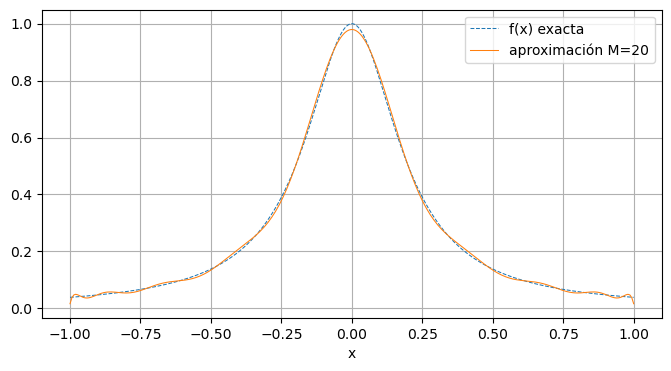

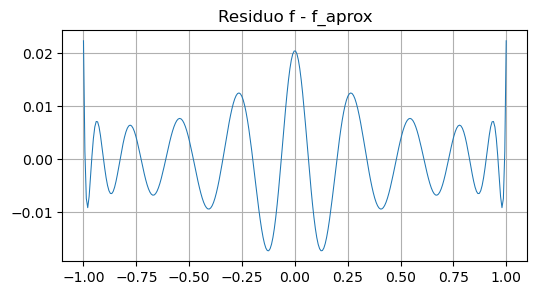

In [9]:
def Nm(x, m): #conjunto de funciones base usados para hacer la aproximacion chi(m)
    """
    Evaluar el polinomio de Legendre de grado m en punto(s) x.
    x puede ser escalar o array-like.
    """
    P = Legendre.basis(m)   
    return P(x)
def gauss_legendre_integral(f, a, b, n=80):
    """
    Integral de f en [a,b] usando cuadratura de Gauss-Legendre con n puntos.
    f: función que acepta array y devuelve array
    """
    xi, wi = leggauss(n)                  # puntos y pesos en [-1,1]
    # mapear xi de [-1,1] a [a,b]
    x_mapped = 0.5*(b-a)*xi + 0.5*(b+a)
    w_mapped = 0.5*(b-a)*wi
    return np.dot(w_mapped, f(x_mapped))
def Ke(i, j, xi, xf, integrator=gauss_legendre_integral, quad_n=80):
    """
    Entrada: índices i,j (grados de los polinomios).
    Calcula K_ij = integral_{xi}^{xf} N_i(x)*N_j(x) dx
    """
    # i = l
    # j = m
    integrand = lambda x: Nm(x, i) * Nm(x, j)
    return integrator(integrand, xi, xf, n=quad_n)
def Fe(i, f_func, xi, xf, integrator=gauss_legendre_integral, quad_n=80):
    """
    Entrada: indice i (grado del polinomio), f_func(x) la función a aproximar.
    Calcula F_i = integral_{xi}^{xf} f(x)*N_i(x) dx
    """
    integrand = lambda x: f_func(x) * Nm(x, i)
    # f_func(x) = funcion que me dio el enunciado
    # Nm = chi(x) Legendre
    return integrator(integrand, xi, xf, n=quad_n)
def assemble_KF(M, f_func, xi, xf, integrator=gauss_legendre_integral, quad_n=80):
    """
    Ensambla la matriz K (MxM) y vector F (Mx1) usando la base Nm con grados 0..M-1.
    """
    K = np.zeros((M, M))
    F = np.zeros(M)
    for i in range(M):
        for j in range(M):
            K[i, j] = Ke(i, j, xi, xf, integrator=integrator, quad_n=quad_n)
        F[i] = Fe(i, f_func, xi, xf, integrator=integrator, quad_n=quad_n)
    return K, F
if __name__ == "__main__":
    # Parámetros
    M = 20                     # número de términos (grados 0..M-1)
    xi = -1.0                   # dominio
    xf =  1.0
    f_func = lambda x: 1.0/(1.0 + 25.0*(x**2))
    # Ensamblar
    K, F = assemble_KF(M, f_func, xi, xf, quad_n=120)
    plt.figure(figsize=(5,4))
    plt.spy(K)
    plt.title("Matriz de rigidez global KG")
    plt.tight_layout()
    plt.figure(figsize=(5,4))
    plt.tight_layout()
    # Resolver el sistema
    a = np.linalg.solve(K, F)
    # Mostrar resultados
    np.set_printoptions(precision=8, suppress=True)
    print("Matriz K (primeros 6x6):\n", K[:min(6,M), :min(6,M)])
    print("\nVector F:\n", F)
    print("\nCoeficientes a:\n", a)
    # Evaluar la aproximación y graficar
    np_points = 300
    X = np.linspace(xi, xf, np_points)
    f_exact = f_func(X)
    f_approx = np.zeros_like(X)
    for j in range(M):
        f_approx += a[j] * Nm(X, j)
    plt.figure(figsize=(8,4))
    plt.plot(X, f_exact, '--', linewidth=0.75, label='f(x) exacta')
    plt.plot(X, f_approx, '-', linewidth=0.75, label=f'aproximación M={M}')
    plt.xlabel('x')
    plt.legend()
    plt.grid(True)
    # Residuo
    plt.figure(figsize=(6,3))
    plt.plot(X, f_exact - f_approx, '-', linewidth=0.75)
    plt.title('Residuo f - f_aprox')
    plt.grid(True)
    plt.show()

In [10]:
def gauss_legendre_integral(f, a, b, n=80):
    """Integra f(x) en [a,b] usando cuadratura Gauss–Legendre con n puntos."""
    xi, wi = leggauss(n)  # puntos y pesos en [-1,1]
    # Mapeo lineal a [a,b]
    x_mapped = 0.5 * (b - a) * xi + 0.5 * (b + a)
    w_mapped = 0.5 * (b - a) * wi
    return np.dot(w_mapped, f(x_mapped))
# ---- Términos locales Ke(i,j) y Fe(i) -----------------------------------
def Ke(i, j, xi, xf, quad_n=80):
    """Calcula el término K_ij = ∫ Nm_i * Nm_j dx"""
    integrand = lambda x: Nm(x, i) * Nm(x, j)
    return gauss_legendre_integral(integrand, xi, xf, n=quad_n)
def Fe(i, f_func, xi, xf, quad_n=80):
    """Calcula el término F_i = ∫ f(x) * Nm_i dx"""
    integrand = lambda x: f_func(x) * Nm(x, i)
    return gauss_legendre_integral(integrand, xi, xf, n=quad_n)
# ---- Ensamblaje global de K y F -----------------------------------------
def assemble_KF(M, f_func, xi, xf, quad_n=80):
    """Construye las matrices globales K y F para el sistema Galerkin."""
    K = np.zeros((M, M))
    F = np.zeros(M)
    for i in range(M):
        for j in range(M):
            K[i, j] = Ke(i, j, xi, xf, quad_n=quad_n)
        F[i] = Fe(i, f_func, xi, xf, quad_n=quad_n)
    return K, F

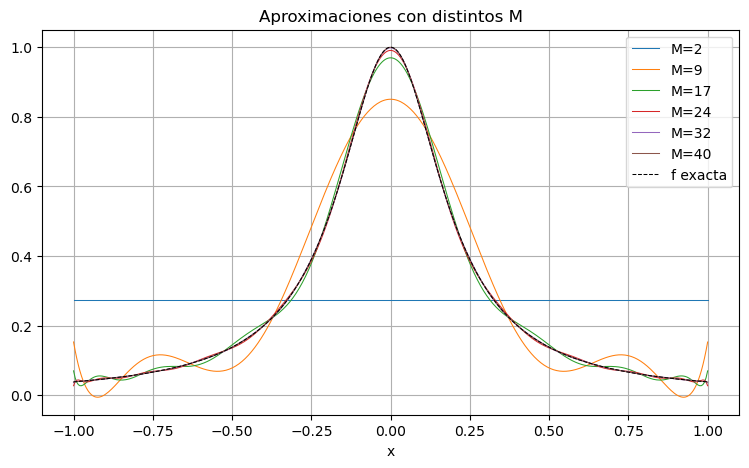

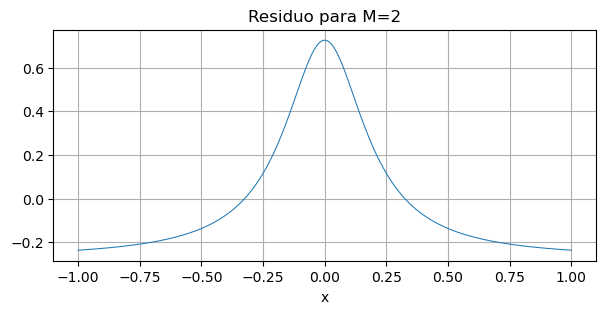

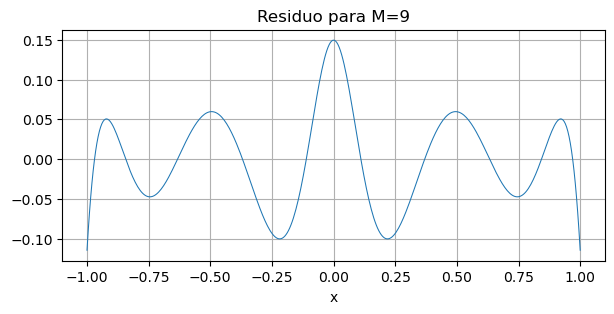

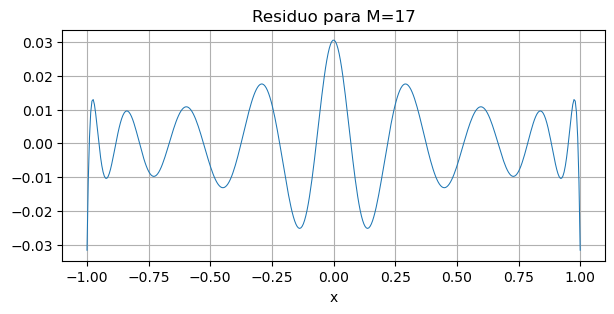

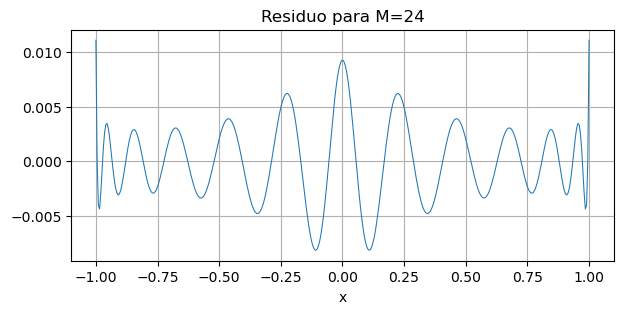

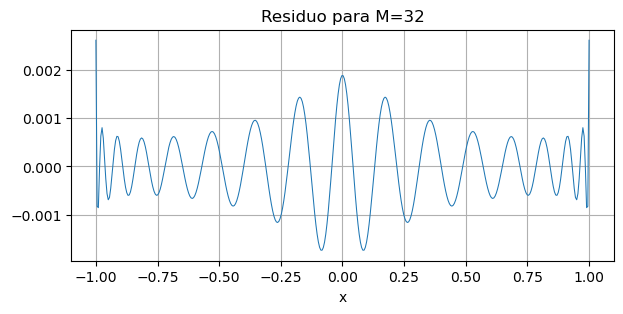

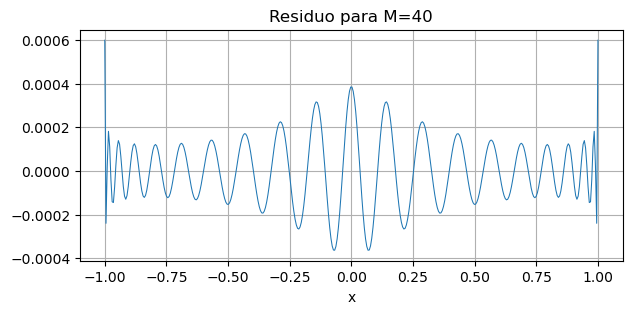

In [14]:
# ============================================================
# Aproximación de f(x) = 1 / (1 + 25x²) con funciones de base Nm
# ============================================================
xi, xf = -1.0, 1.0
f_func = lambda x: 1.0 / (1.0 + 25.0 * x**2)
# Puntos para graficar y comparar
X = np.linspace(xi, xf, 400)
f_exact = f_func(X)
# ---- Funciones base ------------------------------------------------------
def Nm(x, m):
    P = Legendre.basis(m)   # crea el polinomio de Legendre de grado m
    return P(x)
# === Barrido en M y graficar aproximaciones ===============================
M_values = np.linspace(2, 40, 6, dtype=int)   # valores de M (puedes ajustar)
plt.figure(figsize=(9, 5))
for M in M_values:
    K, F = assemble_KF(M, f_func, xi, xf, quad_n=120)
    a = np.linalg.solve(K, F)
    f_approx = np.zeros_like(X)
    for j in range(M):
        f_approx += a[j] * Nm(X, j)
    plt.plot(X, f_approx, lw=0.75, label=f'M={M}')
plt.plot(X, f_exact, 'k--', lw=0.75, label='f exacta')
plt.xlabel('x')
plt.title('Aproximaciones con distintos M')
plt.legend()
plt.grid(True)
plt.show()
# === Graficar residuos individuales =======================================
for M in M_values:
    K, F = assemble_KF(M, f_func, xi, xf, quad_n=120)
    a = np.linalg.solve(K, F)
    f_approx = np.zeros_like(X)
    for j in range(M):
        f_approx += a[j] * Nm(X, j)
    R = f_exact - f_approx
    plt.figure(figsize=(7,3))
    plt.plot(X, R, lw=0.75)
    plt.title(f'Residuo para M={M}')
    plt.xlabel('x')
    plt.grid(True)
plt.show()


# Solucion de ejemplo 2 cambiando la base de funciones de aproximacion 
Aproximacion de la funcion 
$
    \frac{1}{1+exp(-40x)} - \frac{1}{2}
$
Con la base funcional $sin(m\pi\frac{x}{2})$

Efectos de que la base no exista en puntos del dominio

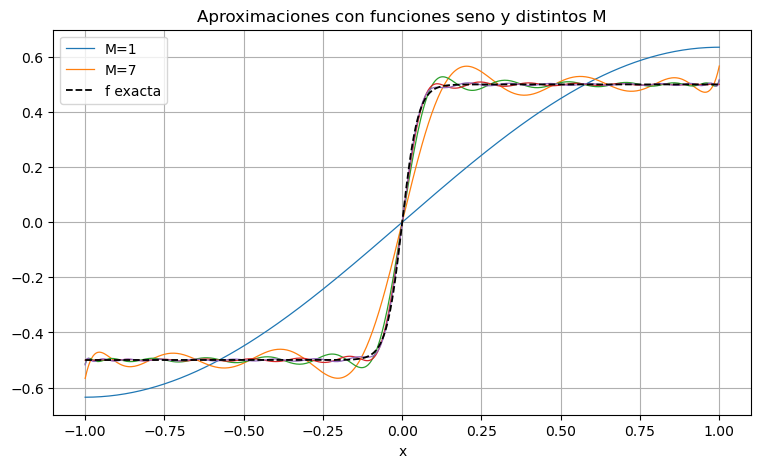

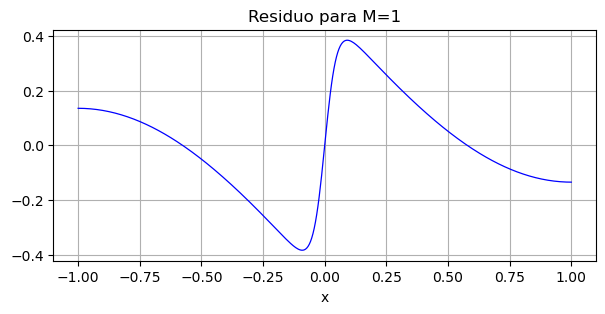

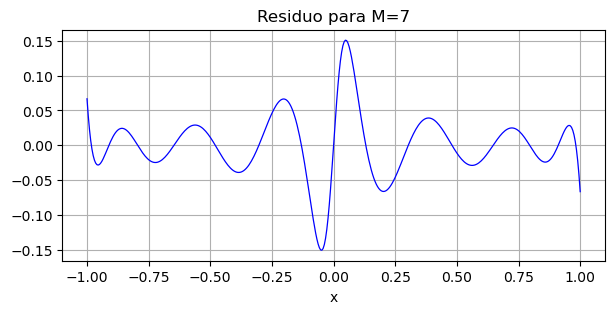

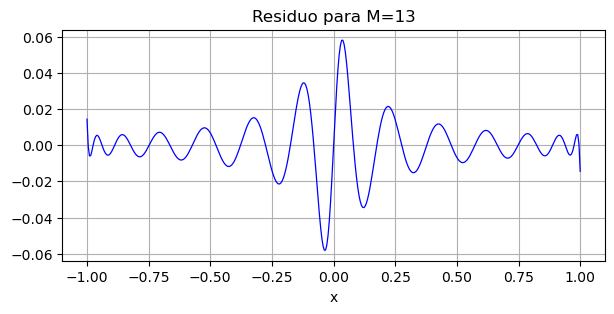

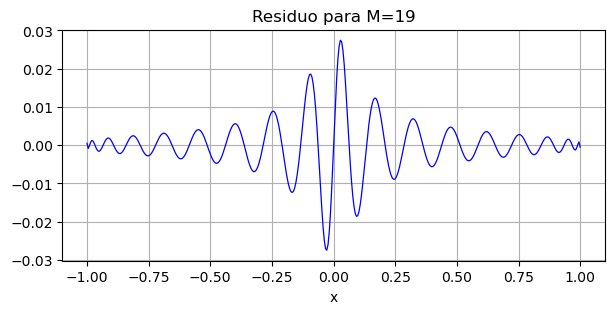

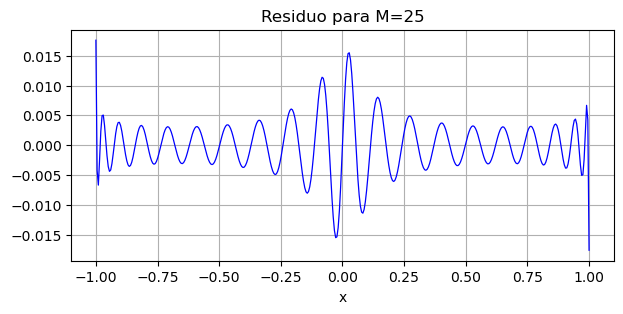

In [16]:
def Nm(x, m):
    """Funciones base seno: N_m(x) = sin(m*pi*x/2), con m >= 1"""
    return np.sin(m * np.pi * x / 2)
def Ke(i, j, xi, xf, quad_n=120):
    """Calcula K_ij = ∫ N_{i+1}(x) * N_{j+1}(x) dx"""
    integrand = lambda x: Nm(x, i+1) * Nm(x, j+1)
    return gauss_legendre_integral(integrand, xi, xf, n=quad_n)
def Fe(i, f_func, xi, xf, quad_n=120):
    """Calcula F_i = ∫ f(x) * N_{i+1}(x) dx"""
    integrand = lambda x: f_func(x) * Nm(x, i+1)
    return gauss_legendre_integral(integrand, xi, xf, n=quad_n)
def assemble_KF(M, f_func, xi, xf, quad_n=120):
    """Construye las matrices K y F usando modos m=1..M."""
    K = np.zeros((M, M))
    F = np.zeros(M)
    for i in range(M):
        for j in range(M):
            K[i, j] = Ke(i, j, xi, xf, quad_n=quad_n)
        F[i] = Fe(i, f_func, xi, xf, quad_n=quad_n)
    return K, F
xi, xf = -1.0, 1.0
f_func = lambda x: 1.0 / (1.0 + np.exp(-40.0 * x)) - 0.5
X = np.linspace(xi, xf, 400)
f_exact = f_func(X)
M_values = np.linspace(1, 25, 5, dtype=int)   # e.g. [1,4,7,11,15]
plt.figure(figsize=(9, 5))
for M in M_values:
    K, F = assemble_KF(M, f_func, xi, xf, quad_n=120)
    # estabilización muy pequeña (opcional) por si la cuadratura falla numericamente
    eps = 0.0   # poner 1e-12 si se quiere regularizar
    if eps > 0:
        K = K + np.eye(M) * eps
    a = np.linalg.solve(K, F)   # ahora K no debe ser singular
    f_approx = np.zeros_like(X)
    for j in range(1, M+1):
        f_approx += a[j-1] * Nm(X, j)
    plt.plot(X, f_approx, lw=0.9, label=f'M={M}' if M in [1,4,7,11,15] else None)
plt.plot(X, f_exact, 'k--', lw=1.3, label='f exacta')
plt.xlabel('x')
plt.title('Aproximaciones con funciones seno y distintos M')
plt.legend()
plt.grid(True)
plt.show()
# ---- Graficar residuos individuales (sin penalización) -------------------
for M in M_values:
    K, F = assemble_KF(M, f_func, xi, xf, quad_n=120)
    a = np.linalg.solve(K, F)
    f_approx = np.zeros_like(X)
    for j in range(1, M+1):
        f_approx += a[j-1] * Nm(X, j)
    R = f_exact - f_approx
    plt.figure(figsize=(7, 3))
    plt.plot(X, R, lw=0.9, color='b')
    plt.title(f'Residuo para M={M}')
    plt.xlabel('x')
    plt.grid(True)

plt.show()

# Solucion del ejemplo 3
Aproximar la función en 
$
exp(-x)x^{1/3}
$
En el dominio (0,1). Efectos de que la base este definida solo en una parte del dominio , o que no este definida en el dominio. Cambio de coordenadas


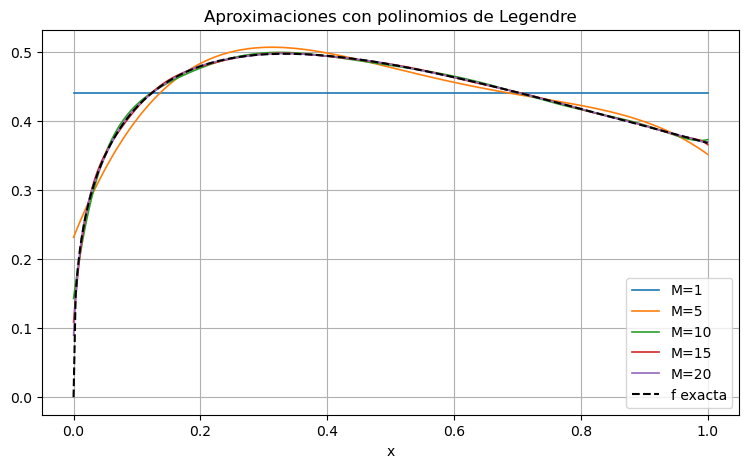

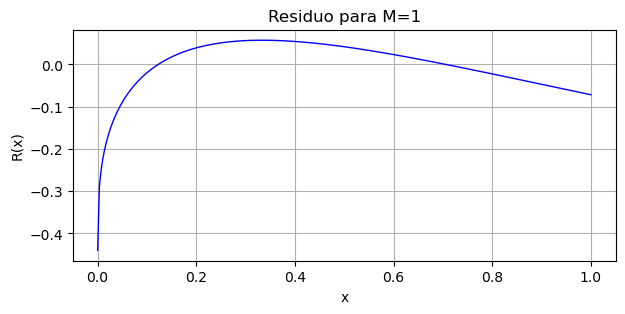

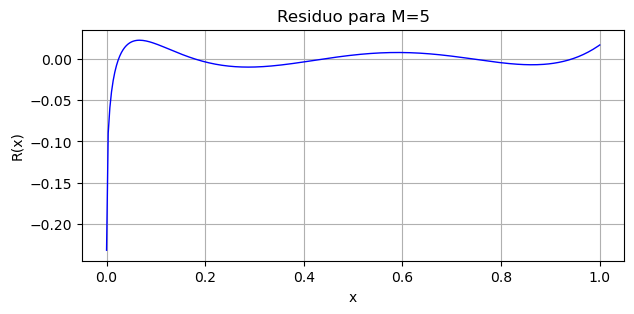

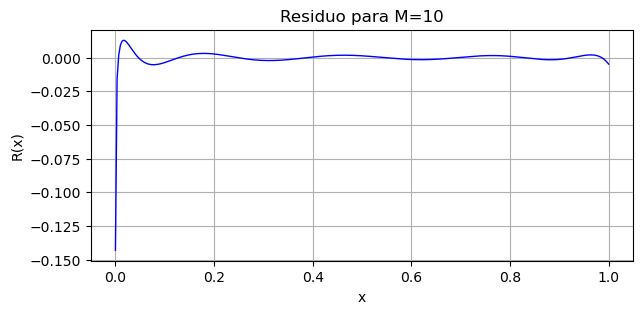

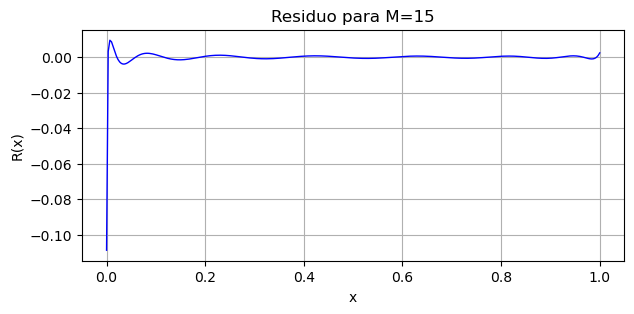

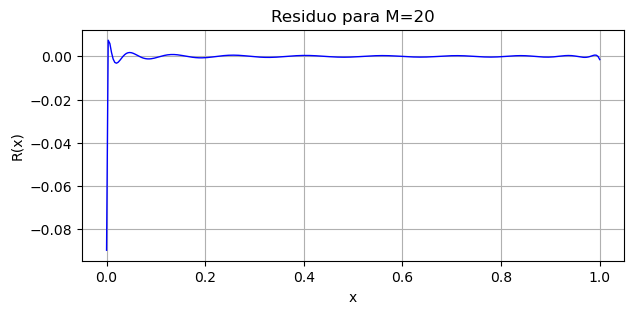

In [112]:
xi, xf = 0.0, 1.0
f_func = lambda x: np.exp(-x) * x**(1/3)
# Cambio de variable: x = (chi + 1)/2 → chi ∈ [-1,1]
f_chi = lambda chi: f_func(0.5 * (chi + 1))
# Funciones base de Legendre
def Nm(x, m):
    P = Legendre.basis(m)   
    return P(x)
# Cuadratura gaussiana para integrar en [-1,1]
def gauss_legendre_quad(func, a=-1, b=1, n=120):
    chi, w = np.polynomial.legendre.leggauss(n)
    return np.sum(w * func(chi)) * (b - a) / 2
# Ensamblaje de K y F
def assemble_KF(M, f_chi):
    K = np.zeros((M, M))
    F = np.zeros(M)
    for i in range(M):
        for j in range(M):
            integrand_K = lambda chi: Nm(chi, i) * Nm(chi, j)
            K[i, j] = gauss_legendre_quad(integrand_K)
        integrand_F = lambda chi: f_chi(chi) * Nm(chi, i)
        F[i] = gauss_legendre_quad(integrand_F)
    return K, F
M_values = np.linspace(1,20,5,dtype=int) 
np_points = 300
X = np.linspace(xi, xf, np_points)
Chi = 2 * X - 1                   # transformar dominio [0,1] → [-1,1]
f_exact = f_func(X)
plt.figure(figsize=(9, 5))
for M in M_values:
    K, F = assemble_KF(M, f_chi)
    a = np.linalg.solve(K, F)
    f_approx = np.zeros_like(X)
    for j in range(M):
        f_approx += a[j] * Nm(Chi, j)
    plt.plot(X, f_approx, lw=1.2, label=f'M={M}')
plt.plot(X, f_exact, 'k--', lw=1.5, label='f exacta')
plt.xlabel('x')
plt.title('Aproximaciones con polinomios de Legendre')
plt.legend()
plt.grid(True)
plt.show()
# === Graficar residuos individuales =======================================
for M in M_values:
    K, F = assemble_KF(M, f_chi)
    a = np.linalg.solve(K, F)
    f_approx = np.zeros_like(X)
    for j in range(M):
        f_approx += a[j] * Nm(Chi, j)
    R = f_exact - f_approx
    plt.figure(figsize=(7, 3))
    plt.plot(X, R, lw=1, color='b')
    plt.title(f'Residuo para M={M}')
    plt.xlabel('x')
    plt.ylabel('R(x)')
    plt.grid(True)
plt.show()